### Mental Health Indicator Code


Average Sleep by PHQ9 Groups:
                      SleepHours  SleepQuality
PHQ9_Groups                                   
Lower Half of Scores        6.90          6.04
Upper Half of Scores        6.95          6.09

Average Sleep by GAD7 Groups:
                      SleepHours  SleepQuality
GAD7_Groups                                   
Lower Half of Scores        6.98          6.10
Upper Half of Scores        6.87          6.02
PHQ9: mean = 8.33, std = 4.75, median =  8.20
GAD7: mean = 7.09, std = 3.88, median =  7.00
SleepHours: mean = 6.92, std = 1.44, median =  7.00
SleepQuality: mean = 6.06, std = 1.95, median =  6.10
                        PHQ9      GAD7  SleepHours  SleepQuality
MentalHealthStatus                                              
At Risk             9.777085  7.937724    6.835698      5.992751
Healthy             4.747776  4.975435    7.143714      6.239265
SleepHoursGrouped
Okay (5-7hours)    753
Good (7-9hours)    738
Poor (<5hours)     190
Great(>9hours    

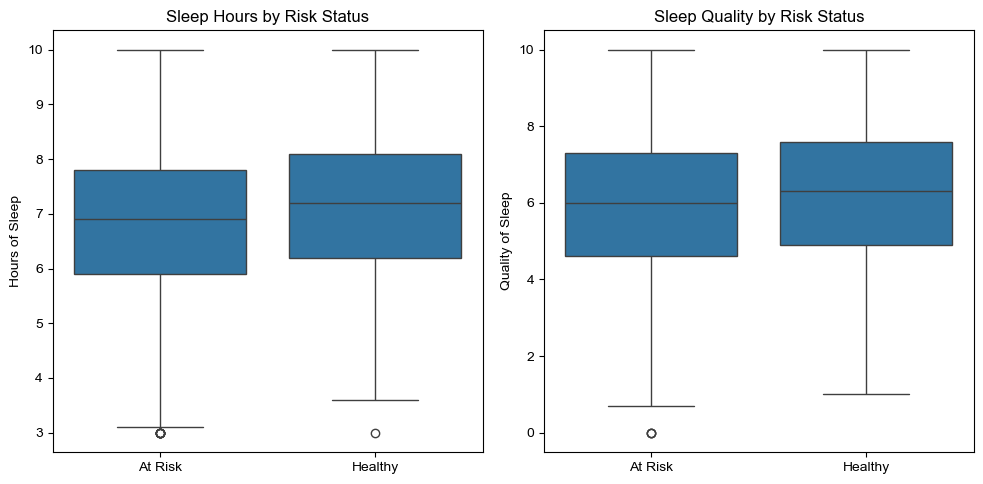

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lxml.html as lx
import os
import sqlite3 as sql
import requests
from re import sub 
%matplotlib inline
plt.rcParams["figure.figsize"] = [5,5]
# Importing tools 

file_path = pd.read_csv("/Users/mackenziehardy/Downloads/data 2.csv") # Cleaned this dataset to use
# only necessary rows using pandas
columns = {
    file_path.columns[0]: 'PHQ9', # Depression score (0-27)
    file_path.columns[1]: 'GAD7', # Anxiety score (0-21)
    file_path.columns[2]: 'SleepHours', # Hours of sleep (3-10)
    file_path.columns[14]: 'SleepQuality', # Quality of sleep 
    file_path.columns[15]: 'MentalHealthStatus' # 1- Healthy, 0 - At risk
}
file_path = file_path.rename(columns = columns)
file_path = file_path[['PHQ9', 'GAD7', 'SleepHours','SleepQuality', 'MentalHealthStatus']] 
# Our new dataset only contains these variables in order to see if there is a correlation
columns = ['PHQ9','GAD7', 'SleepHours','SleepQuality'] # Contains variables that have values
# other than 0 and 1 (excludes MentalHealthStatus)
summary = pd.DataFrame({ # Creates a summary table using pandas
    'Mean': [np.mean(file_path[column]) for column in columns], # Mean of each variable using numpy
    'Median': [np.median(file_path[column]) for column in columns], #Median of each variable using numpy
    'StandardDev': [np.std(file_path[column]) for column in columns], # Standard deviation using numpy
    'Minimum': [np.min(file_path[column]) for column in columns], # Minimum score using numpy
    'Maximum': [np.max(file_path[column]) for column in columns] # Maximum score using numpy
}, index = columns).round(2) # Rounds to nearest hundredth

# Gathers upper half and lower half of depression scores using numpy
file_path['PHQ9_Groups'] = np.where(file_path['PHQ9'] <= file_path['PHQ9'].median(),
                                    'Lower Half of Scores', 'Upper Half of Scores') 
# Gathers the mean of the upper and lower half grouped by hours of sleep and quality
PHQ9_SleepHours = file_path.groupby('PHQ9_Groups')[['SleepHours', 'SleepQuality']].mean().round(2)
# Gathers upper half and lower half of anxiety scores using numpy
file_path['GAD7_Groups'] = np.where(file_path['GAD7'] <= file_path['GAD7'].median(),
                                    'Lower Half of Scores', 'Upper Half of Scores')
# Gathers the mean of the upper and lower half grouped by hours of sleep and quality
GAD7_SleepHours = file_path.groupby('GAD7_Groups')[['SleepHours', 'SleepQuality']].mean().round(2)
print('\nAverage Sleep by PHQ9 Groups:') # Title for PHQ9 
print(PHQ9_SleepHours) # PHQ9 group means
print('\nAverage Sleep by GAD7 Groups:') # Title for GAD7
print(GAD7_SleepHours) # GAD7 group means

for column in columns: # Grabs the columns
    # The mean amount of sleep hours, quality, and scores using numpy
    print(f'{column}: mean = {np.mean(file_path[column]):.2f}, '
    # The standard deviation  of sleep hours, quality, and scores using numpy
    f'std = {np.std(file_path[column]):.2f}, '
    # The median amount  of sleep hours, quality, and scores using numpy
    f'median = {np.median(file_path[column]): .2f}')

# Now mapping the Mental Health Status variable
file_path['MentalHealthStatus'] = file_path['MentalHealthStatus'].map({1: 'Healthy', 0: 'At Risk'})
# Grouping by those at risk and those healthy
print(file_path.groupby('MentalHealthStatus')[columns].mean())
# Grouping hours of sleep in order to make graph readable using pandas
file_path['SleepHoursGrouped'] = pd.cut(file_path['SleepHours'],
                                    bins = [0,5,7,9,10], # Grouping of hours
                                    # Labels for each group
                                    labels = ['Poor (<5hours)', 'Okay (5-7hours)', 
                                              'Good (7-9hours)', 'Great(>9hours'])

print(file_path['SleepHoursGrouped'].value_counts()) # Prints the averages of each 
# variable compared to mental health status
# Creates a style and size for visual
fig, axs = plt.subplots(1,2, figsize = (10,5))
sns.set_theme(style = 'white', palette = 'Set2')

#Sleephours by mental health status
# Creates a box-plot comparing two variables
sns.boxplot(x = 'MentalHealthStatus', y = 'SleepHours', data=file_path, ax=axs[0])
# Labels the graph
axs[0].set(title = 'Sleep Hours by Risk Status', xlabel = '', ylabel = 'Hours of Sleep')

#Sleepquality by mental health status
# Creates a box-plot comparing two variables
sns.boxplot(x = 'MentalHealthStatus', y = 'SleepQuality', data=file_path, ax=axs[1])
# Labels the graph 
axs[1].set(title = 'Sleep Quality by Risk Status', xlabel = '', ylabel = 'Quality of Sleep')

plt.tight_layout()
plt.show()
plt.close()

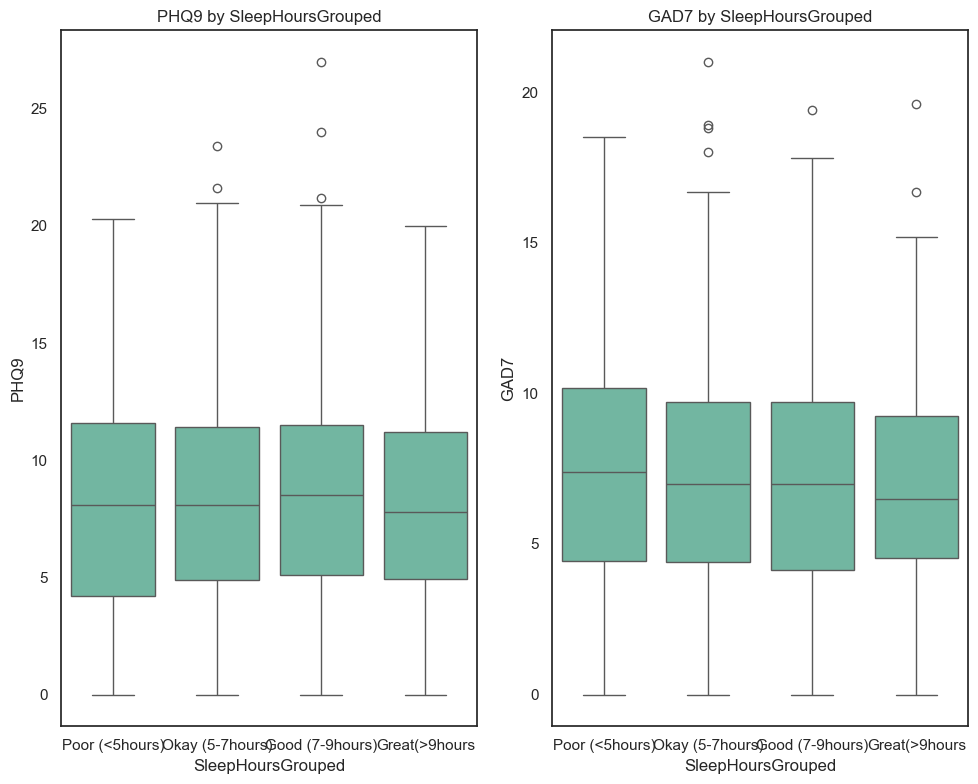

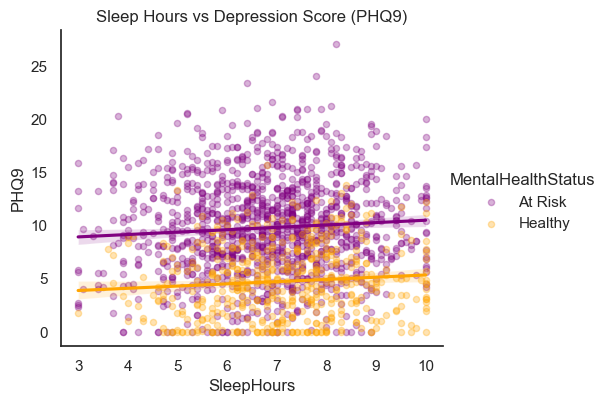

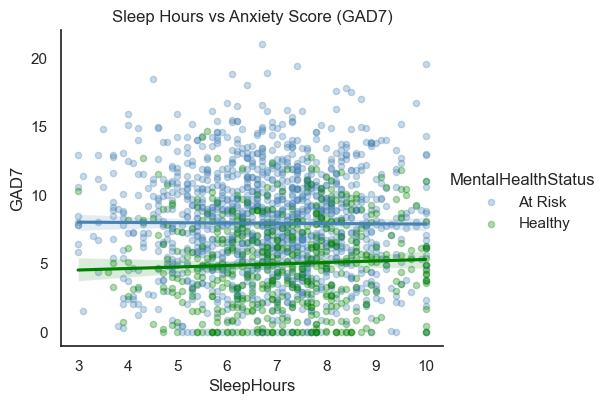

In [16]:
columns_for_boxplot = ['PHQ9', 'GAD7', 'SleepHours','SleepQuality'] # Grabs columns excluding
# Mental health status
fig, axs = plt.subplots(1,2,figsize = (10,8)) # Defines size for the boxplot
# Pairs our previous groupings with the scores from PHQ9 and GAD7
sleep_pairings = [('SleepHoursGrouped' , 'PHQ9'), ('SleepHoursGrouped', 'GAD7')] 
for ax, (x,y) in zip(axs.flatten(), sleep_pairings):
    # Creates a boxplot for both variables
    sns.boxplot(x=x, y=y, data=file_path, ax=ax)
    # Creates titles for boxplots
    ax.set(title = f'{y} by {x}', xlabel = x, ylabel = y)
plt.tight_layout()
plt.show()
plt.close()

# Creates lmplot (linear model) of sleep hours compared to depression score
sns.lmplot(data=file_path, x = 'SleepHours', y = 'PHQ9', height = 4, 
           # Dividies specific points by mental health status
           aspect = 1.2, hue = 'MentalHealthStatus',
           # Those 'at risk' have purple points, those 'healthy' have orange
           scatter_kws = dict(alpha = 0.3, s = 20),palette = {'At Risk': 'purple', 'Healthy': 'orange'})
plt.title('Sleep Hours vs Depression Score (PHQ9)') # Titles the graph
plt.show()
plt.close()

# Creates lmplot (linear model) of sleep hours compared to anxiety score
sns.lmplot(data=file_path, x = 'SleepHours', y = 'GAD7', height = 4, 
           # Dividies specific points by mental health status
           # Those 'at risk' blue, those 'healthy' green
           aspect = 1.2, hue = 'MentalHealthStatus', 
           scatter_kws = dict(alpha = 0.3, s = 20),palette = {'At Risk': 'steelblue', 'Healthy': 'green'}) # 
plt.title('Sleep Hours vs Anxiety Score (GAD7)') # Titles the graph
plt.show()
plt.close()

